<div style="font-size: 36px; font-weight: bold;">
Handwritten Digit Recognition Using Deep Learning
</div>

**Facilitator:** Mr Bilal Kurban, Ms Priyanka Bairapura, Ms Roxanne Spiteri (CBM)

# Setting up the Prerequisites to Build your Deep Learning Project

---

The prerequisites and best practices for setting up a neural network using a local Jupyter notebook involve setting up a clean, isolated environment and installing specific libraries and tools.

## (Optional) Project Environment and Isolation (Containers)

A crucial best practice for managing projects on your laptop is to use **containers**. This practice ensures that your project remains neat, nice, packaged, and isolated, preventing potential dependency conflicts with other projects or the central instance on your computer.

The required containers include:

*   **Virtual Environment**. The below demonstrates using virtual environments for setup.
*   **Docker Container**. While virtual environments are used in the demonstration, a Docker container is also noted as an acceptable alternative if preferred.

### Steps for Setting up the Virtual Environment

To proceed with building a neural network, you can first set up and activate a virtual environment so that any actions performed in Python or PIP (like installing libraries) affect only that environment, not the whole computer.:

#### One-Time Setup Script for Anaconda on Windows

Open the Anaconda Prompt (not CMD or PowerShell), then run the following line-by-line or save it in a .bat file:

1. Set environment name and Python version

`set ENV_NAME=myenv`

`set PYTHON_VERSION=3.10`

2. Create the conda environment

`conda create -y -n %ENV_NAME% python=%PYTHON_VERSION%`

3. Activate the environment

`conda activate %ENV_NAME%`

4. Install ipykernel to make the env available in Jupyter

`conda install -y ipykernel`

5. Register the kernel with Jupyter

`python -m ipykernel install --user --name=%ENV_NAME% --display-name "Python (%ENV_NAME%)"`

#### How to Use the New Environment in Jupyter Notebook

1.	Launch Jupyter Notebook from the Anaconda Navigator or via:bash `jupyter notebook`
2.	When creating a new notebook, go to Kernel > Change kernel > Python (myenv).

#### Best Practices to Avoid Conflicts Further

- Use a unique environment per project: Name it after the project (e.g., env_projectA, env_projectB).
- Avoid installing packages globally: Always install them inside the active environment.
- Use environment.yml files for version control of dependencies.
- Deactivate environments when switching projects: Use conda deactivate before activating another.

## Setting up the Jupyter Environment (Kernel and Libraries)

You will be using **Jupyter notebooks** to build up the neural networks on your laptop. To ensure the notebook functions correctly, you must establish the necessary environment components:

1.  **Select the Kernel**: You must ensure that the correct kernel (conda env base or the one associated with your virtual environment) is selected for your notebook.
3.  **Install Required Libraries**: Essential machine learning and visualization libraries must be installed *inside* the virtual environment/kernel only once:
    *   **TensorFlow**: This is necessary to run the neural network. If the necessary kernel does not have TensorFlow installed, the notebook will report an error ("module name TensorFlow is not installed"). To install Tensorflow you can run the following line `pip install tensorflow`
    *   **Matplotlib**: This is another required library. If it is missing, the notebook will also raise an error. To install Matplotlib you can run the following line `pip install matplotlib` If any other library is missing, you must also install it using PIP.


# Importing and Preparing a Dataset for Deep Learning

---

## Library Importing

This exercise focuses on utilizing **Jupyter notebooks** to construct a neural network. The primary high-level library employed is **Keras**. Keras functions as a **wrapper around the TensorFlow library**, offering a simplified experience. It is described as a **higher-level API** that allows users to build a neural network in potentially only one or two lines of code, unlike TensorFlow, which might require ten lines for the same task. This simplification means the exercise does not require delving into the older, detailed functionalities of TensorFlow. We will also use matplotlib for creating a figure and showing images.


In [68]:
# Import TensorFlow and Keras for building and training neural networks, and Matplotlib for plotting and visualizing data.
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

## Dataset Acquisition and Selection

Following the importation of necessary libraries, the next crucial step is loading a dataset. Keras provides a collection of simple, [built-in datasets](https://keras.io/api/datasets/)
.

1.  **Primary Dataset (MNIST):** The dataset used in the demonstration is the **MNIST digits classification dataset**. This set contains images of **handwritten digits** that the neural network attempts to classify.
2.  **Alternative Dataset (Fashion MNIST):** Another readily available option is the **Fashion MNIST dataset**, which consists of images of clothing items such as coats, T-shirts, jeans, and boots. Participants are highly recommended to repeat the exercise using the Fashion MNIST dataset.
3.  **Grayscale vs. Color:** It is important to note that the MNIST dataset is **grayscale** (containing only black, white, and grays), represented by a single layer of numbers. If alternative datasets are used, care must be taken, as some are **RGB (colored) photos**, which consist of three layers of numerical values.


In [71]:
# Assign the MNIST dataset loader module from Keras to the variable mnist
mnist = keras.datasets.mnist

## Data Loading, Structure and Split

The dataset is loaded directly from Keras using a command structure such as `keras.datasets.[name].load_data()`. Upon loading, the data is automatically partitioned into four variables: **x_train, y_train, x_test and y_test**.

### Data Dimensions and Pixel Values
*   The **training data set** contains **60,000 images**.
*   The **testing data set** contains **10,000 instances**.
*   Each image is **28 by 28 pixels**.
*   Images are composed of pixels, each possessing a value that determines its appearance. These pixel values range from **zero to 255**. A higher numerical value corresponds to a **wider or brighter pixel**.


In [73]:
# Load and unpack the MNIST dataset into training and test images with their corresponding labels
(X_train_full, y_train_full),(X_test,y_test) = mnist.load_data()

In [75]:
# Access X_train_full
X_train_full

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [77]:
# Return the dimensions (shape) of the X_train_full
X_train_full.shape

(60000, 28, 28)

In [79]:
# Return the dimensions (shape) of the X_test
X_test.shape

(10000, 28, 28)

In [81]:
# Access the first element (index 0) of the array or list X_train_full
X_train_full[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

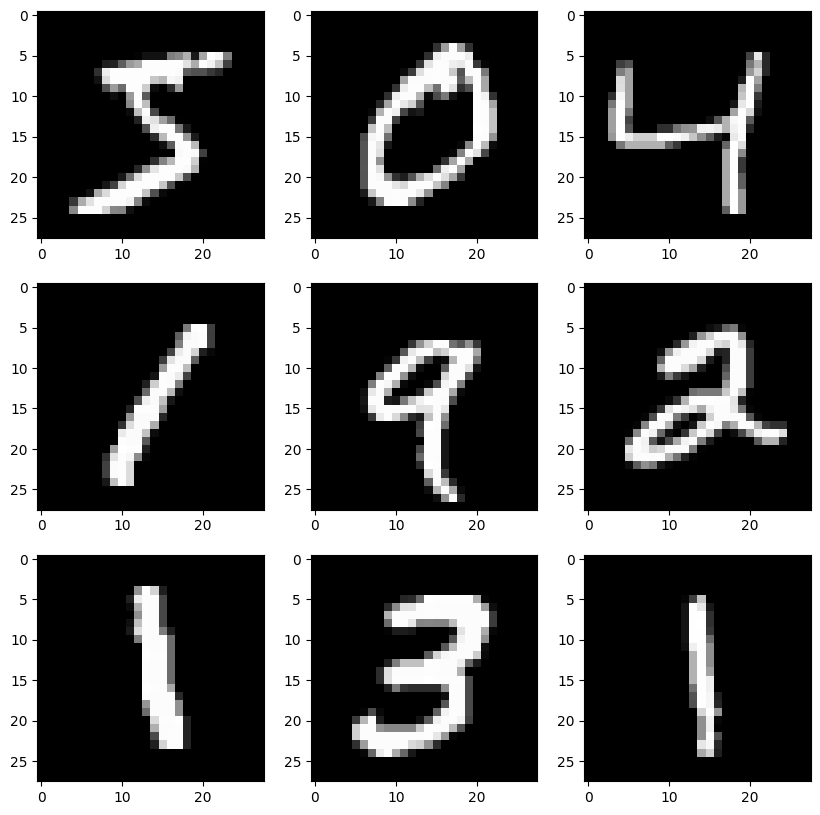

In [83]:
# Create a figure with a 3×3 grid of axes
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10,10))
# Initialize an index to iterate through X_train_full
a = 0
# Iterate over rows and columns of the grid and move to the next image
for i in range(3):
    for j in range(3):        
        axes[i, j].imshow(X_train_full[a], cmap=plt.get_cmap('gray'))
        a = a + 1
# Render the figure
plt.show()

## Data Transformation and Normalization

Before training the network, the data must undergo specific transformations:

1.  **Normalization of Input:**
    *   **Rationale:** Normalization is essential because having input values that vary significantly (e.g., many zeros mixed with values up to 255) can induce **unstabilizations** within the neural network, making the learning process more difficult.
    *   **Procedure:** To mitigate this, all input values must be scaled to a range of **zero to one**. This is achieved by **dividing all pixel values by 255**. This normalization must be applied to the training data, validation data and testing data.
    *   **Labels (Y Values):** The corresponding Y values (labels), which range only from zero to nine, do not require division by 255.

2.  **Creation of a Validation Data Set:**
    *   A **validation dataset** is necessary in addition to the training and testing sets.
    *   The validation set serves as an **internal test** during training.
    *   The model trains across a number of iterations called **epochs**. After each epoch, the validation set allows the model to check against examples it has not previously seen.
    *   This internal testing allows the network to **generalize better** and helps prevent **overfitting** during the process of updating its internal values.
    *   In the example, the validation dataset is created by reserving the **first 5,000 instances** from the initial training data.


In [87]:
# Split the training data into validation and training sets
# X_valid = first 5,000 images from X_train_full, normalized to range [0, 1] by dividing by 255
# X_train = remaining 55,000 images, also normalized.
X_valid, X_train = X_train_full[:5000] / 255, X_train_full[5000:]/255
# y_valid and y_train = corresponding labels
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
# Normalize the test set
# X_test = all test images scaled to [0, 1]
X_test = X_test/255

In [89]:
# Access the first element (index 0) of the array or list X_valid
X_valid[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

## Defining Class Names

The final preparation step involves defining class names. This involves assigning a **string value** to the numerical output classes. While the MNIST dataset uses numbers (0 through 9) as labels, if a different dataset—such as the Fashion MNIST dataset—is used, the numerical labels must be changed to corresponding names (e.g., coat, jacket, jeans, boots) for correct output interpretation.


In [138]:
y_train

array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8)

In [112]:
# Create a list called class_names containing string labels "0" through "9" to represent the ten digit classes in the MNIST dataset.
class_names = ["0","1","2","3","4","5","6","7","8","9"]

In [176]:
# Take the second label in y_train (since indexing starts at 0) as an example to check class names are correct
class_names[y_train[1]]

'3'

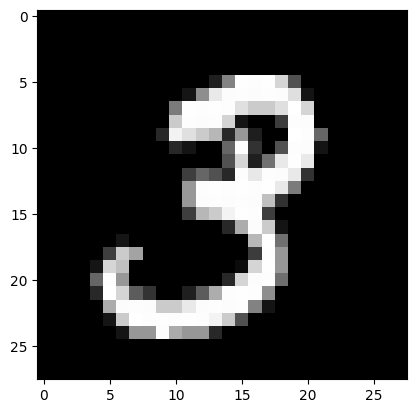

In [178]:
# See the picture if it is correct
plt.imshow(X_train[1], cmap=plt.get_cmap('gray'))

# Building, Compiling and Training the Neural Network

---

The core task involves building the first neural network using the **Keras** library. The model is constructed by sequentially adding layers.

## Model Construction and Architecture

The model is initialized using the **Sequential class**, which is the simplest of the three ways to create models in Keras, allowing the user to select predefined layers. The process involves: `model = keras.models.sequential()` followed by adding subsequent layers.

### Layer Definitions

1.  **Input Layer (Flatten)**:
    *   The initial data input is a $28 \times 28$ matrix.
    *   The input layer's primary role is to **flatten** this matrix, converting it into a single long string of pixels.
    *   The resulting input shape is **784 pixels** ($28 \times 28$).

2.  **Hidden Layers (Dense)**:
    *   All internal layers are referred to as **dense layers**. In a dense layer, **every neuron is connected to every other** neuron in the preceding and succeeding layers.
    *   **First Hidden Layer**: Contains **300 neurons**.
    *   **Second Hidden Layer**: Contains **100 neurons**.
    *   **Activation Function**: The activation for the hidden layers is set to **ReLU** (Rectified Linear Unit), which is noted as one of the best choices for hidden layers.

3.  **Output Layer**:
    *   The network requires **10 output layers (neurons)** because the goal is to classify images into **10 different classes** (digits 0 through 9).
    *   The model predicts the likelihood of the image belonging to each of these 10 classes.
    *   **Activation Function (Softmax)**: **Softmax** is used because the classes are independent (an image can only be one thing). Softmax ensures that the **summation of all predicted possibilities leads to one** (they sum to one). If the possibility of an image being one number is higher, the possibility of it being another number must be lower. In contrast, Sigmoid creates probabilities that are independent from each other.

### Parameters (Learned Values)

The model contains **trainable parameters**—values that are learned during training.
*   **Weights**: Located at every connection between two neurons, initialized randomly.
*   **Biases**: Associated with every neuron, usually initialized to zero.
The total count of these parameters determines the complexity of the model, which aims to update these weights and biases to achieve the best accuracy possible.


In [221]:
# Define the input layer for 28×28 grayscale images with a Sequential model (a linear stack of layers)
# First layer: Convert (Flatten) each 28×28 image into a 1D vector of 784 features, Input shape: [28, 28]
# Add a fully connected hidden layer with 300 neurons, Activation: ReLU (introduces non-linearity)
# Another hidden layer with 100 neurons, also using ReLU
# Output layer with 10 neurons (one per digit class), Activation: Softmax (outputs probabilities for classification)
model = keras.models.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [223]:
# Display a summary of the model architecture, including each layer’s type, output shape and the number of trainable parameters
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [225]:
# Return a list of all layers in the model as Python objects, allowing you to inspect or access each layer’s configuration and properties
model.layers

[<Flatten name=flatten_2, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

## Model Compilation

The compilation phase involves setting **hyper-parameters**, which are hard-coded settings that **cannot be learned** by the model.

1.  **Loss Function**:
    *   The purpose of loss functions is to compute the quantity that a model should seek to minimize during training.
    *   The function used to measure how well the model is performing.
    *   **Sparse Categorical Cross Entropy** is selected because the problem involves classification with **two or more labeled classes**.
    *   For other options in keras you can check [available losses](https://keras.io/api/losses/).

2.  **Optimizer**:
    *   The algorithm used to adjust the weights and biases. The demonstration uses **Stochastic Gradient Descent (SGD)**, which serves as the foundational choice. Keras provides other optimizers (e.g., ADAM, ADAGRAD) that can be used, for example, to make the model run faster.
    *   For other options in keras you can check [available optimizers](https://keras.io/api/optimizers/#available-optimizers)

3.  **Metrics**:
    *   Metrics specify what the model should report during training, beyond just the loss. **Accuracy** is typically added here.
    *   For other options in keras you can check [available metrics](https://keras.io/api/metrics/).


In [227]:
# Prepare the model for training by defining how it will learn and how success will be measured
# Loss function: sparse_categorical_crossentropy (used for multi-class classification when labels are integers)
# Optimizer: sgd (Stochastic Gradient Descent) to update weights during training
# Metrics: accuracy to monitor performance during training and evaluation
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

## Model Training (`model.fit`)

The final step is fitting the model to the data, which requires defining crucial training parameters.

1.  **Epochs**:
    *   An **epoch** defines how many times the model will be run on the **entire dataset**. The training example uses **30 epochs**.
    *   An epoch is one complete pass through the entire training dataset by the model during training.
    *   Multiple epochs help the model gradually improve its weights and reduce error.

2.  **Batch Size (Mini-Batches)**:
    *   The **batch size** determines the number of data points given to the model at one time.
    *   The batch size is a hyperparameter that defines the number of samples to work through before updating the internal model parameters.
    *   Using a small batch size (e.g., 32 examples) allows for the use of **mini-batches**.
    *   The weights and biases are updated using **backpropagation** and **gradient descent** after processing each mini-batch, rather than waiting for the entire dataset. This approach is used because updating after every data point is slow.
    *   *Note on Performance*: It is suggested that the batch size be set to an increment of two (e.g., 16, 32, 64) because this aligns with how computer processors handle the underlying calculations, potentially speeding up training.

3.  **Validation Data**:
    *   This data is used as an internal test; after every epoch, the model checks against examples it has not yet seen.
    *   Monitoring the validation data is critical for detecting **overfitting**: if the **training loss continues to decrease**, but the **validation loss begins to increase**, the model is overfitting to the training data.
    *   *Alternative Setting*: Instead of passing a separate dataset, one can set a `validation_split` (e.g., $0.1$) to automatically set aside a portion of the training set for validation.
4.  **Other Arguments**:
    *   You can also use [other arguments](https://keras.io/api/models/model_training_apis/#fit-method) in `fit` method.


In [229]:
# Start training the model on X_train and y_train
# epochs=30 -> The model will make 30 complete passes through the training data.
# batch_size=32 -> Training data is split into mini-batches of 32 samples for each gradient update.
# validation_data=(X_valid, y_valid) -> After each epoch, the model evaluates performance on the validation set to monitor overfitting.
# history object stores training logs:
  # history.history['loss'] → training loss per epoch
  # history.history['accuracy'] → training accuracy per epoch
  # history.history['val_loss'] → validation loss per epoch
  # history.history['val_accuracy'] → validation accuracy per epoch
history = model.fit(X_train, y_train, epochs=30, validation_data = (X_valid, y_valid), batch_size=32) # also possible to use validation_split=0.1

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7138 - loss: 1.0531 - val_accuracy: 0.9114 - val_loss: 0.3102
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9105 - loss: 0.3089 - val_accuracy: 0.9288 - val_loss: 0.2443
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9290 - loss: 0.2487 - val_accuracy: 0.9436 - val_loss: 0.2025
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9409 - loss: 0.2041 - val_accuracy: 0.9490 - val_loss: 0.1800
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9472 - loss: 0.1820 - val_accuracy: 0.9524 - val_loss: 0.1678
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9535 - loss: 0.1582 - val_accuracy: 0.9590 - val_loss: 0.1457
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9594 - loss: 0.1425 - val_accuracy: 0.9628 - val_loss: 0.1335
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9624 - loss: 0.1327 - 

# Evaluating Neural Network Performance

---

This section details the critical steps for evaluating the trained neural network model, including monitoring performance metrics, interpreting predictions, and identifying areas for further optimization.

## Monitoring Training and Validation Performance

During training, it is essential to monitor how the model’s performance changes over time by tracking both training and validation metrics.

1.  **Loss and Accuracy Tracking**: Both **training loss and accuracy** and **validation loss and accuracy** are tracked.
    *   **Loss Trend**: Both the training loss and the validation loss (represented by blue and green lines) should decrease. However, the **training loss typically gets lower faster**, while the validation loss decreases a little bit slower.
    *   **Accuracy Trend**: Training accuracy increases quicker toward the end. Validation accuracy also improves, but less dramatically.

2.  **Detecting Overfitting**: Observing the relationship between training and validation accuracy is key to identifying **overfitting**. Overfitting would manifest if the training accuracy continued to increase sharply, while the validation accuracy remained more or less static. In the demonstrated model, this overfitting pattern was not observed.

## Managing the Model State

When re-running experiments, maintaining the desired model state is crucial.

*   **Starting From Scratch**: To **refresh the model** and begin training from an empty state, the cell containing the model definition must be run again.
*   **Continued Training**: If only the compilation or fitting steps are rerun, the model will continue training from its existing, already trained state, meaning the weights will be updated upon their current values.


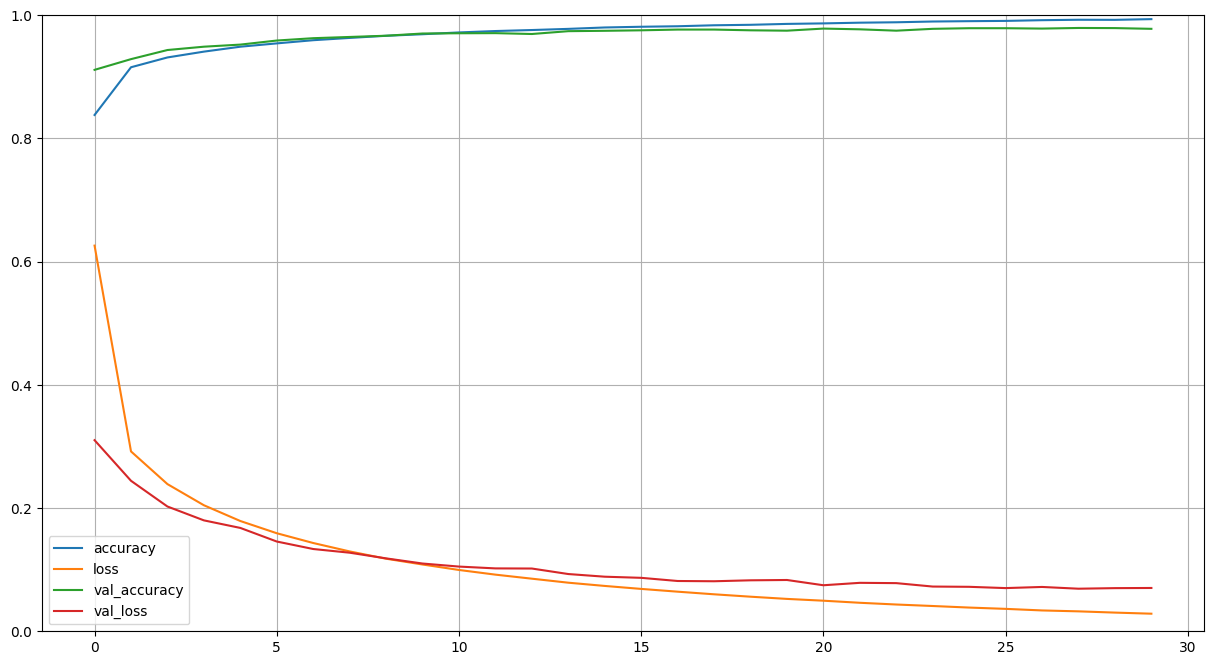

In [231]:
# This visualization helps you see how training and validation accuracy and loss evolve over epochs.
# Convert history.history into a pandas DataFrame
# Plot all metrics (loss, accuracy, val_loss, val_accuracy) on the same graph.
# Set figure size to 15×8, adds grid lines, and limit the y-axis to 0–1 for clarity
# Display the plot

import pandas as pd

pd.DataFrame(history.history).plot(figsize=(15,8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

## Testing the Final Model

The final performance check assesses how the trained model performs on the previously unseen test set.

*   **Test Set Results**: The model demonstrated an exemplary loss of **0.07** and an accuracy of **0.98** on the test set.


In [233]:
# evaluate how well the model generalizes to unseen data
# Run the trained model on the test dataset (X_test, y_test) to measure its performance
# Compute the loss (using the same loss function defined in compile) and any metrics specified (e.g., accuracy)
# Return a list like [test_loss, test_accuracy].
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9728 - loss: 0.0900


[0.07434750348329544, 0.9768999814987183]

## Generating and Analyzing Predictions

After evaluating the aggregate performance, detailed analysis of the model's predictions is performed.

1.  **Raw Predictions**: Using the `model.predict` function on the test set inputs generates an array (of length 10) for each test example. This array shows the **possibility or probability** the model assigned to each of the 10 possible classes (digits 0, 1, 2, etc.).

2.  **Interpreting Results**: To determine the definitive predicted class, the **ARG MAX function** is applied. This function identifies the class with the highest probability (e.g., predicting 7, 2, or 1 as the final output).

3.  **Confusion Matrix Visualization**: The best way to visualize specific performance errors is by generating a **confusion matrix**.
    *   **Calculation**: A confusion matrix is calculated using the **TensorFlow confusion matrix function**.
    *   **Visualization**: The visualization uses the **Seaborn module** because it provides **nicer looking graphics** and **nicer colors** compared to Matplotlib.
    *   **Heat Map Interpretation**: A **heat map** is typically employed, often using a greens color scheme, where higher numbers of correct or confused instances are represented by a **really dark green**, and lower numbers by a brighter green.
    *   **Successful Classification**: A successful model shows a **nice diagonal line**, indicating that most examples (e.g., zeros and ones) were correctly classified.
    *   **Error Identification**: Off-diagonal cells with high values indicate confusion; for example, the analysis showed that **threes and fives were confused with each other** (which is plausible for handwritten digits).


In [38]:
# generate predictions for all samples in X_test using the trained model, returning an array of probability distributions for each class (digits 0–9).
model.predict(X_test)

array([[8.85112684e-07, 1.71122263e-08, 8.25329425e-06, ...,
        9.99789894e-01, 1.08017964e-07, 5.76227194e-06],
       [1.66134419e-06, 1.68108963e-04, 9.99661207e-01, ...,
        2.43008543e-12, 5.81361965e-05, 1.38614103e-11],
       [1.07759774e-06, 9.98648345e-01, 1.28091953e-04, ...,
        4.97219735e-04, 4.82539326e-04, 1.15231433e-05],
       ...,
       [2.82010082e-09, 5.89176485e-11, 9.75709402e-10, ...,
        1.17686295e-05, 1.54674842e-06, 4.21015357e-05],
       [1.04065494e-08, 3.61036783e-08, 1.26232941e-10, ...,
        3.28352212e-09, 2.39443580e-05, 7.09543813e-11],
       [1.04332321e-06, 3.57779396e-11, 1.53102022e-07, ...,
        1.26918762e-11, 8.08796674e-09, 9.30828137e-10]], dtype=float32)

In [244]:
# make probability predictions on the test dataset X_test. The output y_prob contains the predicted probabilities for each class
# y_prob.argmax(axis=-1) finds the index of the maximum probability in each row of y_prob
  # axis=-1 means it operates across the last axis (i.e., across the class probabilities for each sample).
# The result is a 1D array y_classes, where each element is the predicted class label (the index of the highest probability).

y_prob = model.predict(X_test)
y_classes = y_prob.argmax(axis=-1)
y_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [246]:
# Compute a confusion matrix comparing the true labels y_test with the predicted labels y_classes, showing how well the classification model performed by counting correct and incorrect predictions for each class.
confusion_matrix = tf.math.confusion_matrix(y_test, y_classes)

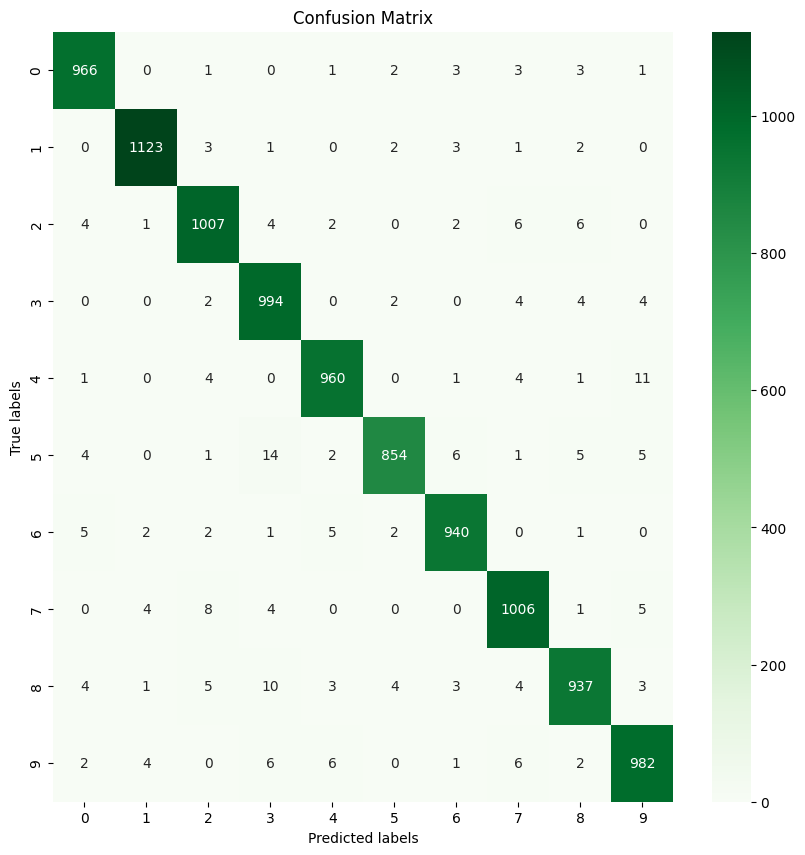

In [248]:
# Create a visual representation of the confusion matrix using Seaborn
# Draw a heatmap of the confusion_matrix.
# annot=True adds numeric values inside each cell.
# fmt='g' ensures numbers are displayed normally (not scientific notation)
# cmap='Greens' applies a green color gradient
# Add Axis Labels and Title
# Replace numeric ticks with class names
# Make the plot larger for readability
# Display the heatmap.


import seaborn as sb    

# ax = plt.figure(figsize=(8, 6))
fig = sb.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Greens')  #annot=True to annotate cells, ftm='g' to disable scientific notation
# labels, title and ticks
fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names) 
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)
plt.show()

## Recommended Next Steps for Hands-on Experimentation

Participants are strongly encouraged to engage in hyperparameter tweaking to try and surpass the achieved accuracy of 0.98. This is considered a fun and highly educational exercise.

**Suggested Areas for Tweak and Experimentation**:

*   **Dataset Use**: Perform the entire exercise again using the **Fashion MNIST dataset**.
*   **Hyperparameter Tuning**: Change the number of **epochs**, or increase or decrease the **batch size**.
*   **Architecture Modification**: Improve the model by **adding a hidden layer** or **increasing the number of neurons** in existing layers.
*   **Activation Functions**: Experiment with **changing the activation functions**.
